# Limpieza de datos con Pandas

Importacion y preparacion del dataset que se usara

In [59]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/data_cleaning/NFL Play by Play 2009-2016 (v3).csv", low_memory=False)

np.random.seed(0)
df.head()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600.0,0.0,TEN,...,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


Ver cuantod valores nulos tiene el dataframe

In [60]:
datos_faltantes = df.isnull().sum()

datos_faltantes[0:10]       # Datos faltantes de las primeras 10 columnas

Date                0
GameID              0
Drive               0
qtr                 0
down            54218
time              188
TimeUnder           0
TimeSecs          188
PlayTimeDiff      374
SideofField       450
dtype: int64

Revisaremos cuanto porcentaje de datos faltan en el dataframe para tener mas claro con lo que estamos trabajando

In [61]:
total_celdas = np.prod(df.shape)
total_faltantes = datos_faltantes.sum()

porcentaje_faltantes = round((total_faltantes/total_celdas) * 100 , 2)
print(porcentaje_faltantes)

27.65


Se observa que mas de un cuarto de los datos faltan en el dataframe

## Imputation

La imputacion en pandas corresponde al proceso de rellenar los valores faltantes o NaN usando metodos, principalmente con df.fillna().

Trabajaremoscon 'TimeSecs' ya que tienen una cantidad de valores nulos notable.

Lo que se ve en esa columna segun la documentacion son los segundos faltantes en el juego cuando la jugada fue realizada.

In [62]:
datos_faltantes[0:10]

Date                0
GameID              0
Drive               0
qtr                 0
down            54218
time              188
TimeUnder           0
TimeSecs          188
PlayTimeDiff      374
SideofField       450
dtype: int64

### Eliminar los valores faltantes

Para remover o eliminar todas las filas con datos faltantes se puede utilizar df.dropna()

Hay que tener cuidado ya que esto eliminara todas las columnas con datos faltantes y en este caso eliminaria la mayor parte del dataset, por lo que no es buena idea.

Tambien se puede eliminar una columna completa la cual tenga al menos un valor faltante, esto se realiza df.dropna(axis=1), el axis 1 especifica las columnas.

### Rellenar los valores faltantes

In [63]:
subset_nfl_data = df.loc[:, 'EPA':'Season'].head()
subset_nfl_data

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,NaN,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,NaN,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,NaN,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


Se pueden llenar los datos faltantes con .fillna(), y se le puede asignar el valor que se desea.

En el ejemplo todos los datos NaN se llenaran con 0.

In [64]:
df_0 = subset_nfl_data.fillna(0)
df_0

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,0.000000,0.000000,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,0.000000,0.000000,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,0.000000,0.000000,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.000000,0.000000,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,0.000000,0.000000,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.000000,0.000000,2009


Tambien se pueden rellenar los valores con el valor que sigue despues del NaN en la misma columna o fila.
- .bfill = el valor de la siguiente fila
- .ffill = el valor de la fila anterior

In [65]:
df_next = subset_nfl_data.bfill(axis=0).fillna(0)
df_next

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,-1.068169,1.146076,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,-0.032244,0.036899,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,3.318841,-5.031425,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.106663,-0.156239,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,0.000000,0.000000,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.000000,0.000000,2009


In [66]:
df_next1 = subset_nfl_data.ffill(axis=0).fillna(0)
df_next1

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,0.000000,0.000000,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,0.000000,0.000000,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,-1.068169,1.146076,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,-0.032244,0.036899,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,3.318841,-5.031425,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.106663,-0.156239,2009


Se pueden aplicar los 2 metodos al mismo tiempo, primero se recorren todas las filas utilizando bfill, y despues ffill evitando que la ultima fila del dataframe quede nula en caso de que exista, ayudando a que el valor sea distinto a 0.

In [67]:
df_next1 = subset_nfl_data.bfill().ffill()
df_next1

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,-1.068169,1.146076,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,-0.032244,0.036899,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,3.318841,-5.031425,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.106663,-0.156239,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,3.318841,-5.031425,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.106663,-0.156239,2009


## Scaling and Normalization

In [68]:
# for Box-Cox Transformation
from scipy import stats

# for min_max scaling
from mlxtend.preprocessing import minmax_scaling

# plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

**Diferencia entre escalar y normalizar**

Son muy similares ya que en ambos caasos se estan transformando los valores de variables numericas, asi los datos transformados tienen propiedades especificas que aportan una ayuda mayor.

- Escalando: Se cambia el rango de los datos.
- Normalizando: Se cacmbia la forma de la distribucion de los datos.

### Scaling

Significa que se estan tranformando los datos para que entre en una escala(rango) especifica, como 0-100 o 0-1. Se utiliza escalar cuando se usan metodos basados en medida de que tan apartados estan los puntos de los datos. 

Como por ejemplo, se reuiere ver el precio de algunos productos en Us dollar y Yen. El Us dolar equivale a 100 yen, por lo que si no se escala algunos metodos consideraran la diferencia de 1 Yen como la diferencia de 1 Us dolar, esto claramento no tiene sentido.

Por lo que escalando las variables, ayuda a una comparacion equitativa de las diferentes variables.

Para el siguiente ejemplo crearemos los datos y los escalaremos entre 0 y 1, para luego crear un grafico para comparar.

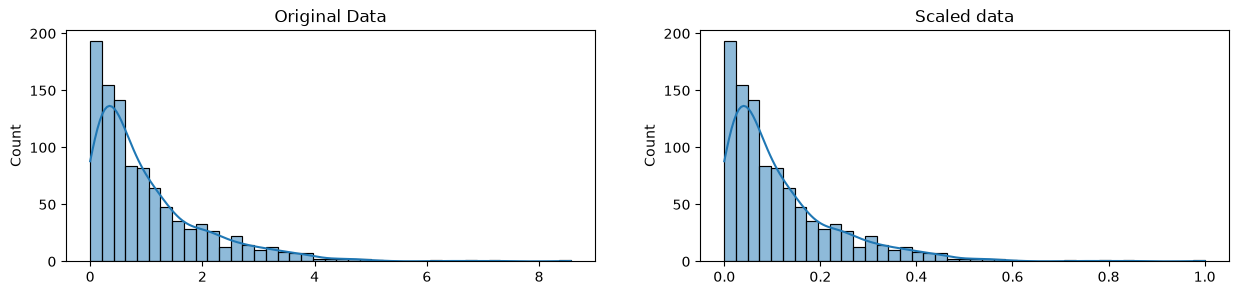

In [69]:
original_data = np.random.exponential(size=1000)

scaled_data = minmax_scaling(original_data, columns=[0])

fig, ax = plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(scaled_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title("Scaled data")
plt.show()

Se aprecia que la forma de los datos no cambia, pero en vez de ir en un rango de 0 a 8, va de rango 0 a 1

### Normalization

**Distribución normal** ("campana de Gauss" o distribución gaussiana): cantidades similares de observaciones caen por encima y por debajo de la media, la media y la mediana coinciden, y hay más observaciones concentradas cerca de la media.

**Cuándo normalizar:** cuando vas a usar una técnica de machine learning o estadística que asume que los datos son normales. Ejemplos: análisis discriminante lineal (LDA) y Naive Bayes gaussiano.

Para el siguiente ejemplo los datos seran normalizados y despues se hara un grafico de comparacion.

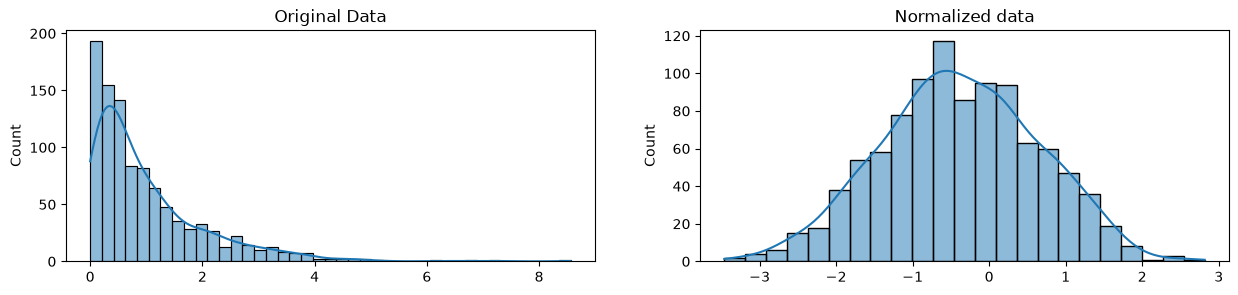

In [70]:
normalized_data = stats.boxcox(original_data)

fig, ax=plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(normalized_data[0], ax=ax[1], kde=True, legend=False)
ax[1].set_title("Normalized data")
plt.show()

La transformación Box-Cox convierte datos numéricos sesgados en datos que se aproximan a una distribución normal, aplicando una función de potencia (x^λ - 1) / λ donde Scipy encuentra automáticamente el mejor valor de λ(lambda) para tu dataset específico. Se usa con stats.boxcox(datos), que devuelve una tupla con los datos transformados y el λ óptimo utilizado, y solo funciona con valores estrictamente positivos (para datos con ceros o negativos existe la alternativa Yeo-Johnson). Es útil antes de aplicar algoritmos que asumen normalidad en los datos, como LDA o Naive Bayes gaussiano.

Diferencia clave:

Scaling:
- Cambia el rango de los valores (ej: 0-1)
- Se usa con algoritmos sensibles a magnitud/escala (ej: SVM, K-NN, regresion con regularizacion)
- Un ejemplo del metodo es el Min-Max Scaling

Normalization:
- Cambia la forma de la distribucion hacia (forma de campana)
- Se usa con algoritmos que asumen normalizacion (ej: LDA, Naive Bayes gaussiano)
- Un ejemplo Box-Cox transformation

## Parsing dates

In [71]:
import datetime

df = pd.read_csv("data/data_cleaning/catalog.csv", low_memory=False)

df.head()

,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,geolocation,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,"(38.600900000000003, -77.268199999999993)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html
1,42,3/22/07,NaN,NaN,United States,US,Ohio,17288,New Philadelphia,3.33522,...,"(40.517499999999998, -81.430499999999995)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,Canton Rep.com,http://www.cantonrep.com/index.php?ID=345054&C...
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,"(40.4377, -79.915999999999997)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...
3,59,4/14/07,NaN,NaN,Canada,CA,Quebec,42786,Châteauguay,2.98682,...,"(45.322600000000001, -73.777100000000004)",Landslide,Riverbank collapse,Small,Rain,NaN,NaN,NaN,Le Soleil,http://www.hebdos.net/lsc/edition162007/articl...
4,61,4/15/07,NaN,NaN,United States,US,Kentucky,6903,Pikeville,5.66542,...,"(37.432499999999997, -82.493099999999998)",Landslide,Landslide,Small,Downpour,NaN,NaN,0.0,Matthew Crawford (KGS),NaN


In [72]:
df['date'].dtype

<StringDtype(storage='python', na_value=nan)>

Para convertir toda la columna de fecha empezaremos cambiando el tipo de dato a datetime.

El siguiente paso sera convertir todas las fechas a un formato especifico, de los cuales los mas comunes son:
- %d = dia
- %m = mes
- %y = año

ejemplo:
- 1/17/07 el formato es "%m/%d/%y"
- 17.1.2007 el formato es "%d-%m-%Y"

In [73]:
df['date_parsed'] = pd.to_datetime(df['date'], format="%m/%d/%y")  # se crea una nueva columna con la fecha parseada o transformada al mismo formato

df['date_parsed'].head()

0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: date_parsed, dtype: datetime64[us]

En caso de tener un error con multiples formatos de fecha, se puede hacer que Pandas infiera el formato de fecha con "infer_datetime_format=True", aunque no es lo recomendable siempre, ya que Pandas no siempre sera capas de inferir que tipo de formato utilizar y tarda mucho mas tiempo que especificar el formato.

Ejemplo: 
- df['date_parsed'] = pd.to_datetime(df['date'], infer_datetime_format=True)


### Extract information of dates

Ahora que toda la columna de fecha esta en el formato correcto, podemos obtener informacion como el dia, mes, año donde algun suceso del dataframe ocurrio.

In [74]:
day_of_month_landslides = df['date_parsed'].dt.day
day_of_month_landslides.head()

0     2.0
1    22.0
2     6.0
3    14.0
4    15.0
Name: date_parsed, dtype: float64

Ahora se puede utilizar el metodo ".dt" ya que la columna es de tipo datetime, ya que el metodo no sabe como comportarse con columnas de tipo object.

<Axes: xlabel='date_parsed', ylabel='Count'>

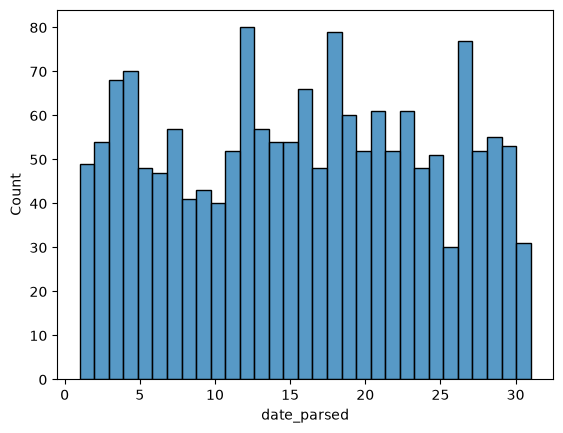

In [75]:
day_of_month_landslides = day_of_month_landslides.dropna()

sns.histplot(day_of_month_landslides, kde=False, bins=31)

## Character Encodings

In [76]:
import charset_normalizer

Los character encodings son conjuntos de reglas que mapean cadenas binarias crudas (como 0110100001101001) a caracteres de texto legible por humanos (como "hi"). Existen muchos encodings distintos, y si intentas leer texto usando un encoding diferente al que fue escrito originalmente, obtienes texto corrupto llamado "mojibake" (ej: æ–‡å—åŒ–ã??) o caracteres "desconocidos" que aparecen como ���������� cuando no existe un mapeo entre un byte y un carácter en el encoding usado. Aunque los desajustes de encoding son menos comunes hoy que antes, siguen siendo un problema real. El encoding estándar que hay que conocer es UTF-8 — todo el código de Python está en UTF-8, y lo ideal es que todos tus datos también lo estén, ya que los problemas surgen justo cuando algo no está en ese formato. En Python 2 manejar encodings era complicado, pero en Python 3 es mucho más simple; ahí trabajarás principalmente con dos tipos de datos de texto, siendo el string el formato de texto por defecto.

In [77]:
before = "This is the euro symbol: €"

type(before)

str

In [78]:
after = before.encode("utf-8", errors="replace")

type(after)

bytes

In [79]:
after

b'This is the euro symbol: \xe2\x82\xac'

In [80]:
print(after.decode("utf-8"))

This is the euro symbol: €


### Reading in files with encoding problems

In [81]:
# kickstarter_2016 = pd.read_csv("data/data_cleaning/ks-projects-201612.csv")

El codigo anterior tiene el error "UnicodeDecodeError", lo que quiere decir que el formato no es UTF-8.

No se sabe que tipo de formato tiene, y una de las manera de saberlo es intentar un monton de formatos diferentes hasta encontrar el correcto. Tambien se puede utilizar "charset_normalizer" para adivinar automaticamente el formato, aunque no es garantizado que encuentre el formato pero si es mas rapido.

Para saber que formato tiene revisaremos los 10.000 primeros bytes del archivo, lo cual usualmente es lo suficiente para saber que tipo de formato tiene el archivo.

In [82]:
with open("data/data_cleaning/ks-projects-201612.csv", 'rb') as rawdata:
    result = charset_normalizer.detect(rawdata.read(20000))

print(result)

{'encoding': 'windows-1250', 'language': 'English', 'confidence': 1.0}


El resultado indica que el formato es "windows-1250", por lo que ahora hay que probar si realmente es el correcto.

In [83]:
kickstarter_2016 = pd.read_csv("data/data_cleaning/ks-projects-201612.csv", encoding="Windows-1252", low_memory=False)

kickstarter_2016.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09 11:36:00,1000,2015-08-11 12:12:28,0,failed,0,GB,0,NaN,NaN,NaN,NaN
1,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26 00:20:50,45000,2013-01-12 00:20:50,220,failed,3,US,220,NaN,NaN,NaN,NaN
2,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16 04:24:11,5000,2012-03-17 03:24:11,1,failed,1,US,1,NaN,NaN,NaN,NaN
3,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29 01:00:00,19500,2015-07-04 08:35:03,1283,canceled,14,US,1283,NaN,NaN,NaN,NaN
4,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01 13:38:27,50000,2016-02-26 13:38:27,52375,successful,224,US,52375,NaN,NaN,NaN,NaN


### Saving your files with UTF-8 encoding

In [84]:
# kickstarter_2016.to_csv("ks-projects-201801-utf8.csv")

## Inconsistent Data Entry

In [86]:
# helpful modules
import fuzzywuzzy
from fuzzywuzzy import process
import charset_normalizer

professors = pd.read_csv("data/data_cleaning/pakistan_intellectual_capital.csv")

C:\Users\nicol\AppData\Roaming\Python\Python314\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Pre-processing data

Para ver con que datos estamos trabajando

In [87]:
professors.head()

,Unnamed: 0,S#,Teacher Name,University Currently Teaching,Department,Province University Located,Designation,Terminal Degree,Graduated from,Country,Year,Area of Specialization/Research Interests,Other Information
0,2,3,Dr. Abdul Basit,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,Software Engineering & DBMS,NaN
1,4,5,Dr. Waheed Noor,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,DBMS,NaN
2,5,6,Dr. Junaid Baber,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,"Information processing, Multimedia mining",NaN
3,6,7,Dr. Maheen Bakhtyar,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,"NLP, Information Retrieval, Question Answering...",NaN
4,24,25,Samina Azim,Sardar Bahadur Khan Women's University,Computer Science,Balochistan,Lecturer,BS,Balochistan University of Information Technolo...,Pakistan,2005.0,VLSI Electronics DLD Database,NaN


Empezaremos con "Country" revisando si tiene datos inconsistentes y limpiarla en caso de que existan.

In [94]:
countries = professors['Country'].unique()

countries = np.array(countries)  # Se transforma a un array de Numpy ya que anterioormente era un StringArray que no tenia metodo sort
countries.sort()
countries

array([' Germany', ' New Zealand', ' Sweden', ' USA', 'Australia',
       'Austria', 'Canada', 'China', 'Finland', 'France', 'Greece',
       'HongKong', 'Ireland', 'Italy', 'Japan', 'Macau', 'Malaysia',
       'Mauritius', 'Netherland', 'New Zealand', 'Norway', 'Pakistan',
       'Portugal', 'Russian Federation', 'Saudi Arabia', 'Scotland',
       'Singapore', 'South Korea', 'SouthKorea', 'Spain', 'Sweden',
       'Thailand', 'Turkey', 'UK', 'USA', 'USofA', 'Urbana', 'germany'],
      dtype=object)

Se aprecia que algunos datos tienen inconsistencia como " New Zealand" y "New Zealand" o "germany" y " Germany".

Por lo que el primer paso es convertir todo a minuscula y despues quitar espacios a ambos lados en caso de que tenga.

In [95]:
# convert to lower case
professors['Country'] = professors['Country'].str.lower()
# remove trailing white spaces
professors['Country'] = professors['Country'].str.strip()

### Use fuzzy matching to correct inconsistent data entry

Volveremos a observar si la columna "Country" contiene algun otra inconsistencia.

In [97]:
countries = professors['Country'].unique()

countries = np.array(countries)
countries.sort()
countries

array(['australia', 'austria', 'canada', 'china', 'finland', 'france',
       'germany', 'greece', 'hongkong', 'ireland', 'italy', 'japan',
       'macau', 'malaysia', 'mauritius', 'netherland', 'new zealand',
       'norway', 'pakistan', 'portugal', 'russian federation',
       'saudi arabia', 'scotland', 'singapore', 'south korea',
       'southkorea', 'spain', 'sweden', 'thailand', 'turkey', 'uk',
       'urbana', 'usa', 'usofa'], dtype=object)

"south korea" y "southkorea" deberian ser iguales.

Por lo que usaremos la libreria de "fuzzywuzzy" que ayuda a identificar que texto son parecidos el uno con el otro.

**Fuzzy matching:** proceso de encontrar automáticamente cadenas de texto muy similares a una cadena objetivo. En general, una cadena se considera "más cercana" a otra mientras menos caracteres necesites cambiar para transformar una en la otra — por ejemplo, "apple" y "snapple" están a dos cambios de distancia (agregar "s" y "n"), mientras que "in" y "on" están a un solo cambio (reemplazar "i" por "o"). No siempre se puede confiar 100% en el fuzzy matching, pero generalmente ahorra al menos algo de tiempo.

In [98]:
# get the top 10 closest matches to "south korea"
matches = fuzzywuzzy.process.extract("south korea", countries, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

# take a look at them
matches

[('south korea', 100),
 ('southkorea', 48),
 ('saudi arabia', 43),
 ('norway', 35),
 ('ireland', 33),
 ('portugal', 32),
 ('singapore', 30),
 ('netherland', 29),
 ('macau', 25),
 ('usofa', 25)]

In [99]:
# function to replace rows in the provided column of the provided dataframe
# that match the provided string above the provided ratio with the provided string
def replace_matches_in_column(df, column, string_to_match, min_ratio = 47):
    # get a list of unique strings
    strings = df[column].unique()
    
    # get the top 10 closest matches to our input string
    matches = fuzzywuzzy.process.extract(string_to_match, strings, 
                                         limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

    # only get matches with a ratio > 90
    close_matches = [matches[0] for matches in matches if matches[1] >= min_ratio]

    # get the rows of all the close matches in our dataframe
    rows_with_matches = df[column].isin(close_matches)

    # replace all rows with close matches with the input matches 
    df.loc[rows_with_matches, column] = string_to_match
    
    # let us know the function's done
    print("All done!")

In [100]:
replace_matches_in_column(df=professors, column='Country', string_to_match="south korea")

All done!


In [102]:
# get all the unique values in the 'Country' column
countries = professors['Country'].unique()

# sort them alphabetically and then take a closer look
countries = np.array(countries)
countries.sort()
countries

array(['australia', 'austria', 'canada', 'china', 'finland', 'france',
       'germany', 'greece', 'hongkong', 'ireland', 'italy', 'japan',
       'macau', 'malaysia', 'mauritius', 'netherland', 'new zealand',
       'norway', 'pakistan', 'portugal', 'russian federation',
       'saudi arabia', 'scotland', 'singapore', 'south korea', 'spain',
       'sweden', 'thailand', 'turkey', 'uk', 'urbana', 'usa', 'usofa'],
      dtype=object)

# Limpieza completa aplicada al dataset NFL

Ahora que revisamos cada técnica por separado, aplicaremos un flujo de limpieza 
completo sobre nuestro dataset original de la NFL: duplicados, corrección de tipos, 
outliers y una columna derivada, para finalmente exportar el dataset limpio.

In [105]:
df = pd.read_csv("data/data_cleaning/NFL Play by Play 2009-2016 (v3).csv", low_memory=False)

### Paso 1: Eliminar filas duplicadas

In [106]:
# Revisamos cuántas filas duplicadas existen antes de eliminarlas
print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")

df = df.drop_duplicates()

print(f"Cantidad de filas después de eliminar duplicados: {df.shape[0]}")

Filas duplicadas encontradas: 0
Cantidad de filas después de eliminar duplicados: 362447


`duplicated()` marca como `True` cada fila que es una copia exacta de otra fila 
anterior. `drop_duplicates()` elimina esas filas repetidas, conservando solo la 
primera aparición de cada una.

### Paso 2: Corregir tipos de datos

Recordemos el `DtypeWarning` que obtuvimos al cargar el dataset — las columnas 
`DefTwoPoint` y `BlockingPlayer` tienen tipos mezclados. Vamos a corregirlas.

In [107]:
# Revisamos el tipo actual de la columna
print(df['DefTwoPoint'].dtype)

# Forzamos la columna a numérica; los valores que no se puedan convertir
# se transforman en NaN en vez de causar un error
df['DefTwoPoint'] = pd.to_numeric(df['DefTwoPoint'], errors='coerce')

print(df['DefTwoPoint'].dtype)

str
float64


`pd.to_numeric()` convierte una columna a tipo numérico. El parámetro 
`errors='coerce'` le dice a pandas que, si encuentra un valor que no puede 
convertir (por ejemplo, texto donde debería haber un número), lo reemplace por 
`NaN` en vez de detener la ejecución con un error. Esto resuelve directamente el 
`DtypeWarning` que vimos al cargar el archivo.

### Paso 3: Detectar y eliminar outliers

Usaremos el método del rango intercuartílico (IQR) sobre la columna `Yards.Gained`, 
que representa las yardas ganadas en cada jugada.

In [108]:
Q1 = df['Yards.Gained'].quantile(0.25)
Q3 = df['Yards.Gained'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Rango normal: entre {limite_inferior} y {limite_superior} yardas")
print(f"Filas antes de filtrar outliers: {df.shape[0]}")

df = df[(df['Yards.Gained'] >= limite_inferior) & (df['Yards.Gained'] <= limite_superior)]

print(f"Filas después de filtrar outliers: {df.shape[0]}")

Rango normal: entre -10.5 y 17.5 yardas
Filas antes de filtrar outliers: 362447
Filas después de filtrar outliers: 331383


El **rango intercuartílico (IQR)** es la diferencia entre el percentil 75 (Q3) y 
el percentil 25 (Q1) — representa dónde se concentra el 50% central de los datos. 
Cualquier valor que caiga 1.5 veces el IQR por debajo de Q1 o por encima de Q3 se 
considera un **outlier** (un valor atípico, como una jugada con una cantidad de 
yardas anormalmente alta o negativa) y se elimina para que no distorsione futuros 
análisis estadísticos.

### Paso 4: Crear una columna derivada

In [109]:
# Columna booleana: True si la jugada ganó yardas positivas, False si no
df['jugada_positiva'] = df['Yards.Gained'] > 0

df[['Yards.Gained', 'jugada_positiva']].head()

,Yards.Gained,jugada_positiva
1,5,True
2,-3,False
3,0,False
4,0,False
5,0,False


Una **columna derivada** se calcula a partir de otras columnas ya existentes, en 
vez de venir directamente en los datos originales. Aquí `jugada_positiva` indica 
si una jugada resultó en ganancia de yardas o no — es un ejemplo simple de cómo 
enriquecer un dataset para facilitar análisis posteriores (por ejemplo, calcular 
el porcentaje de jugadas exitosas por equipo).

### Paso 5: Exportar el dataset limpio

In [111]:
df.to_csv('data/nfl_play_by_play_clean.csv', index=False)

print("Dataset limpio exportado correctamente.")
print(f"Forma final del dataset: {df.shape}")

Dataset limpio exportado correctamente.
Forma final del dataset: (331383, 103)


Guardamos el resultado final en un nuevo archivo CSV, dejando el dataset original 
intacto en `data/` y el dataset ya limpio disponible para su uso en análisis 
posteriores (EDA, visualizaciones, modelos, etc.).

# Conslusion

En esta práctica apliqué un flujo completo de limpieza de datos sobre el dataset 
real de jugadas de la NFL (2009-2016), cubriendo las técnicas fundamentales del 
proceso: manejo de valores nulos (`isnull`, `fillna`, `dropna`, `bfill`/`ffill`), 
escalado y normalización de datos (incluyendo la transformación Box-Cox), parsing 
de fechas, corrección de encodings de texto, y estandarización de texto 
inconsistente mediante fuzzy matching.

Como cierre, apliqué un pipeline completo sobre el dataset original: eliminé 
filas duplicadas, corregí el tipo de dato de columnas con tipos mezclados 
(resolviendo el `DtypeWarning` inicial), detecté y eliminé outliers usando el 
método del rango intercuartílico (IQR), creé una columna derivada (`jugada_positiva`) 
y exporté el resultado final a un nuevo archivo CSV limpio.